<b>
<p>
<center>
<font size="5">
Predictive Maintenance: NASA Turbofan Engine Degradation
</font>
</center>
</p>

<p>
<center>
<font size="4">
Machine Learning I - DATS 6202 Spring 2026
</font>
</center>
</p>

<p>
<center>
<font size="3">
By: Armin Soroosh, Luca Guerra, Alex Biuckinas
</font>
</center>
</p>


<p>
<center>
<font size="3">
Instructor: Yuxiao (James) Huang
</font>
</center>
</p>
</b>

# Introduction

Turbofan jet engines are standard and by far the most dominantly used engine type in commercial aviation. Their unexpected failure can result in dramatic consequences such as unplanned for maintenance or even air disasters. Because of this, predictive maintenance could be a key factor in aviation safety in not only limiting unplanned for maintenance on the aircraft but also the prevention of catastrophic disasters and lives being lost. By continuously monitoring sensor data collected during engine operation, machine learning models can learn the degradation patterns of an engine and successfully estimate its Remaining Useful Life (RUL). RUL is measured as the number of operational cycles remaining before the engine is likely to fail.

This project applies multiple different models such as Linear Regression, Random Forest, Long Short-Term Memory (LSTM), and XGBoost. We predict XGBoost will be the most accurate model because engine degradation is a non-linear process where wear accelerates as an engine approaches failure. XGBoost is also well-suited to the high-dimensional nature of the CMAPSS dataset, which contains 21 sensor readings per cycle, many of which are noisy or redundant. This model’s built-in regularization prevents it from overfitting to irrelevant sensors, making it better suited for this type of problem.

The NASA CMAPSS dataset, which is a widely used benchmark for predictive maintenance research, simulates the sensor readings of turbofan engines. The goal of this project is to accurately predict the RUL from multivariable time-series sensor data, allowing maintenance teams to intervene at the optimal moment to prevent potential aviation disasters.

Dataset: [NASA Turbofan Engine Degradation Simulation](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/)

**Note: This is a simulated dataset, however we received special permission from Dr. Huang.

# Experiment

# Notebook Configuration

## Google Drive

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Get the absolute path of the current folder
abspath_curr = '/content/drive/MyDrive/Colab Notebooks/MLproject/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Warning

In [ ]:
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

## Matplotlib

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Set matplotlib sizes
plt.rc('font', size=20)
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=20)
plt.rc('figure', titlesize=20)

## Random Seed

In [ ]:
import numpy as np

random_seed = 42

np.random.seed(random_seed)

# Data Preprocessing

## Load Data

In [ ]:
!pip install xgboost --quiet

import time
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Column names
index_names   = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = [
    '(Fan inlet temperature) (◦R)',
    '(LPC outlet temperature) (◦R)',
    '(HPC outlet temperature) (◦R)',
    '(LPT outlet temperature) (◦R)',
    '(Fan inlet Pressure) (psia)',
    '(bypass-duct pressure) (psia)',
    '(HPC outlet pressure) (psia)',
    '(Physical fan speed) (rpm)',
    '(Physical core speed) (rpm)',
    '(Engine pressure ratio(P50/P2)',
    '(HPC outlet Static pressure) (psia)',
    '(Ratio of fuel flow to Ps30) (pps/psia)',
    '(Corrected fan speed) (rpm)',
    '(Corrected core speed) (rpm)',
    '(Bypass Ratio) ',
    '(Burner fuel-air ratio)',
    '(Bleed Enthalpy)',
    '(Required fan speed)',
    '(Required fan conversion speed)',
    '(High-pressure turbines Cool air flow)',
    '(Low-pressure turbines Cool air flow)'
]
col_names = index_names + setting_names + sensor_names

In [ ]:
# Load raw training data
df_raw_train = pd.read_csv(abspath_curr + '/train_FD001.txt', sep='\s+', header=None, names=col_names)

# Make copy of df_raw_train
df_train = df_raw_train.copy(deep=True)

# Load raw test data
df_raw_test = pd.read_csv(abspath_curr + '/test_FD001.txt', sep='\s+', header=None, names=col_names)

# Make copy of df_raw_test
df_test = df_raw_test.copy(deep=True)

# Load the RUL for the test set
df_test_RUL = pd.read_csv(abspath_curr + '/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])

# Get name of target
target = 'RUL'

In [ ]:
# df_train dimensions
pd.DataFrame([[df_train.shape[0], df_train.shape[1]]], columns=['# rows', '# columns'])

,# rows,# columns
0,20631,26


In [ ]:
# first 5 rows of df_train
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,(Fan inlet temperature) (◦R),(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(Fan inlet Pressure) (psia),...,(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Burner fuel-air ratio),(Bleed Enthalpy),(Required fan speed),(Required fan conversion speed),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow)
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Drop Constant-Value Features

In [ ]:
# Identify and drop constant variable features
sens_const_values = []
for feature in setting_names + sensor_names:
    try:
        if df_train[feature].min() == df_train[feature].max():
            sens_const_values.append(feature)
    except:
        pass

print('Dropped (constant):', sens_const_values)
df_train.drop(sens_const_values, axis=1, inplace=True)
df_test.drop(sens_const_values,  axis=1, inplace=True)

Dropped (constant): ['setting_3', '(Fan inlet temperature) (◦R)', '(Fan inlet Pressure) (psia)', '(Engine pressure ratio(P50/P2)', '(Burner fuel-air ratio)', '(Required fan speed)', '(Required fan conversion speed)']


In [ ]:
# Print columns
list(df_train.columns)

['engine',
 'cycle',
 'setting_1',
 'setting_2',
 '(LPC outlet temperature) (◦R)',
 '(HPC outlet temperature) (◦R)',
 '(LPT outlet temperature) (◦R)',
 '(bypass-duct pressure) (psia)',
 '(HPC outlet pressure) (psia)',
 '(Physical fan speed) (rpm)',
 '(Physical core speed) (rpm)',
 '(HPC outlet Static pressure) (psia)',
 '(Ratio of fuel flow to Ps30) (pps/psia)',
 '(Corrected fan speed) (rpm)',
 '(Corrected core speed) (rpm)',
 '(Bypass Ratio) ',
 '(Bleed Enthalpy)',
 '(High-pressure turbines Cool air flow)',
 '(Low-pressure turbines Cool air flow)']

## Compute RUL

The training data runs up to the point of engine failure. The RUL at each cycle is computed as `max_cycle - current_cycle`.
An upper cap of **125 cycles** is applied — RUL prediction is only meaningful near end-of-life.

In [ ]:
# Define the maximum life of each engine (last observed cycle = failure point)
df_train_RUL = df_train.groupby(['engine']).agg({'cycle': 'max'})
df_train_RUL.rename(columns={'cycle': 'life'}, inplace=True)

# Merge life back onto the training data
df_train = df_train.merge(df_train_RUL, how='left', on=['engine'])

# Compute RUL at each cycle
df_train['RUL'] = df_train['life'] - df_train['cycle']
df_train.drop(['life'], axis=1, inplace=True)

# Cap RUL at 125 — only prediction near end-of-life is meaningful
df_train['RUL'][df_train['RUL'] > 125] = 125

df_train.head()

,engine,cycle,setting_1,setting_2,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125


## Feature Selection

Backward stepwise regression is used to remove features with statistically insignificant p-values (threshold = 0.05).

In [ ]:
# Container for the selected features
Selected_Features = []

def backward_regression(X, y, threshold_out=0.05, verbose=True):
    """Select features using Backward Stepwise Regression.

    Args:
        X              -- feature values (DataFrame)
        y              -- target variable (Series)
        threshold_out  -- p-value threshold above which a feature is dropped
        verbose        -- if True, print each dropped feature

    Returns:
        list of selected feature names
    """
    included = list(X.columns)
    while True:
        changed = False
        # Fit OLS with current feature set
        model   = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # Get p-values (exclude the intercept)
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f'worst_feature : {worst_feature}, {worst_pval}')
        if not changed:
            break
    Selected_Features.append(included)
    print(f'\nSelected Features:\n{Selected_Features[0]}')


# Apply backward regression on the training data (exclude engine id and target)
X = df_train.iloc[:, 1:-1]
y = df_train.iloc[:, -1]
backward_regression(X, y)

worst_feature : setting_1, 0.35895295902011237
worst_feature : setting_2, 0.182298536546937

Selected Features:
['cycle', '(LPC outlet temperature) (◦R)', '(HPC outlet temperature) (◦R)', '(LPT outlet temperature) (◦R)', '(bypass-duct pressure) (psia)', '(HPC outlet pressure) (psia)', '(Physical fan speed) (rpm)', '(Physical core speed) (rpm)', '(HPC outlet Static pressure) (psia)', '(Ratio of fuel flow to Ps30) (pps/psia)', '(Corrected fan speed) (rpm)', '(Corrected core speed) (rpm)', '(Bypass Ratio) ', '(Bleed Enthalpy)', '(High-pressure turbines Cool air flow)', '(Low-pressure turbines Cool air flow)']


In [ ]:
# Store the selected feature names
feature_names = Selected_Features[0]
len(feature_names)

16

## Prepare Train and Test Sets

In [ ]:
# For the test set: keep only the last cycle per engine (the prediction point)
df_test_cycle = df_test.groupby(['engine']).agg({'cycle': 'max'})
df_test_cycle.rename(columns={'cycle': 'life'}, inplace=True)
df_test_max = df_test.merge(df_test_cycle, how='left', on=['engine'])
df_test_max = df_test_max[(df_test_max['cycle'] == df_test_max['life'])]
df_test_max.drop(['life'], axis=1, inplace=True)

In [ ]:
# Extract features and targets
X_train = df_train[feature_names]
y_train = df_train.iloc[:, -1]
X_test  = df_test_max[feature_names]
y_test  = df_test_RUL.iloc[:, -1]

In [ ]:
# Scale features to [0, 1] using MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

# Print dimensions
pd.DataFrame(
    [[X_train.shape[0], X_train.shape[1]], [X_test.shape[0], X_test.shape[1]]],
    index=['Train', 'Test'],
    columns=['# rows', '# features']
)

,# rows,# features
Train,20631,16
Test,100,16


# Modelling and Evaluation

In [ ]:
# Initialise the model performance tracker
model_performance = pd.DataFrame(columns=['R2', 'RMSE', 'MAE', 'time to train', 'time to predict', 'total time'])

# Number of test engines (used for per-engine line plots)
n_test_engines = len(df_test['engine'].unique())


def plot_actual_vs_predicted(name, y_true, y_pred):
    """Scatter plot of actual vs predicted RUL."""
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.scatterplot(x=y_true, y=y_pred, s=100, alpha=0.6,
                    linewidth=1, edgecolor='black', ax=ax)
    sns.lineplot(x=[min(y_true), max(y_true)],
                 y=[min(y_true), max(y_true)],
                 linewidth=4, color='gray', ax=ax)
    ax.set_title(f'Actual vs Predicted — {name}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.annotate(
        text=('R-squared error: ' + '{:.2%}'.format(r2_score(y_true, y_pred)) + '\n' +
              'Root Mean Squared Error: ' + '{:.2f}'.format(mean_squared_error(y_true, y_pred, squared=False))),
        xy=(0, max(y_true) * 0.85),
        size='medium'
    )
    sns.despine()
    plt.tight_layout()
    plt.show()


def plot_engine_predictions(name, y_true, y_pred, n_engines):
    """Line plot of actual vs predicted RUL per engine."""
    fig, ax = plt.subplots(figsize=(20, 5))
    sns.lineplot(x=np.arange(n_engines), y=y_true,
                 color='gray',      label='actual',      ax=ax)
    sns.lineplot(x=np.arange(n_engines), y=y_pred,
                 color='steelblue', label='predictions', ax=ax)
    ax.set_ylabel('RUL')
    ax.set_xlabel('Engine nr')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

## Linear Regression

In [ ]:
%%time
start = time.time()

# Train the Linear Regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
end_train = time.time()

# Generate predictions on the test set
y_predictions_lr = model_lr.predict(X_test)
end_predict = time.time()

# Record model performance
model_performance.loc['Linear Regression'] = [
    r2_score(y_test, y_predictions_lr),
    np.sqrt(mean_squared_error(y_test, y_predictions_lr)),
    mean_absolute_error(y_test, y_predictions_lr),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('R-squared error: '  + '{:.2%}'.format(model_lr.score(X_test, y_test)))
print('Root Mean Squared Error: ' + '{:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_predictions_lr))))

R-squared error: 70.62%
Root Mean Squared Error: 22.52
CPU times: user 36.5 ms, sys: 0 ns, total: 36.5 ms
Wall time: 61.7 ms


## Random Forest

In [ ]:
%%time
start = time.time()

# Train the Random Forest model
model_rf = RandomForestRegressor(
    n_jobs=-1,
    n_estimators=500,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=random_seed
)
model_rf.fit(X_train, y_train)
end_train = time.time()

# Generate predictions on the test set
y_predictions_rf = model_rf.predict(X_test)
end_predict = time.time()

# Record model performance
model_performance.loc['Random Forest'] = [
    r2_score(y_test, y_predictions_rf),
    np.sqrt(mean_squared_error(y_test, y_predictions_rf)),
    mean_absolute_error(y_test, y_predictions_rf),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('R-squared error: ' + '{:.2%}'.format(model_rf.score(X_test, y_test)))
print('Root Mean Squared Error: ' + '{:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_predictions_rf))))

R-squared error: 81.59%
Root Mean Squared Error: 17.83
CPU times: user 1min 3s, sys: 461 ms, total: 1min 4s
Wall time: 51.1 s


## XGBoost

In [ ]:
%%time
start = time.time()

# Train the XGBoost model
model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_seed,
    n_jobs=-1,
    verbosity=0
)
model_xgb.fit(X_train, y_train)
end_train = time.time()

# Generate predictions on the test set
y_predictions_xgb = model_xgb.predict(X_test)
end_predict = time.time()

# Record model performance
model_performance.loc['XGBoost'] = [
    r2_score(y_test, y_predictions_xgb),
    np.sqrt(mean_squared_error(y_test, y_predictions_xgb)),
    mean_absolute_error(y_test, y_predictions_xgb),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('R-squared error: ' + '{:.2%}'.format(r2_score(y_test, y_predictions_xgb)))
print('Root Mean Squared Error: ' + '{:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_predictions_xgb))))

R-squared error: 80.49%
Root Mean Squared Error: 18.36
CPU times: user 2.67 s, sys: 16.2 ms, total: 2.68 s
Wall time: 1.4 s


## LSTM

In [ ]:
import tensorflow as tf
import sklearn

from tensorflow import keras
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [ ]:
seq_len = 30

def build_sequences(df, feature_cols, seq_len):
    """Slide a window of length seq_len over each engine's cycles."""
    X, y = [], []
    for engine_id, grp in df.groupby('engine'):
        feats = grp[feature_cols].values
        rul   = grp['RUL'].values
        for i in range(seq_len, len(feats)):
            X.append(feats[i-seq_len:i])
            y.append(rul[i])
    return np.array(X), np.array(y)

def build_test_sequences(df, feature_cols, seq_len, scaler):
    """For each test engine, take the last seq_len cycles as its input sequence."""
    X = []
    for engine_id, grp in df.groupby('engine'):
        feats = grp[feature_cols].values
        seq = feats[-seq_len:] if len(feats) >= seq_len else np.pad(feats, ((seq_len - len(feats), 0), (0, 0)), mode='edge')
        X.append(seq)
    X = np.array(X)
    n, s, f = X.shape
    return scaler.transform(X.reshape(-1, f)).reshape(n, s, f)

X_seq, y_seq = build_sequences(df_train, feature_names, seq_len)

sc_seq = MinMaxScaler()
n_samples, n_steps, n_feats = X_seq.shape
X_seq_scaled = sc_seq.fit_transform(X_seq.reshape(-1, n_feats)).reshape(n_samples, n_steps, n_feats)

from sklearn.model_selection import train_test_split
X_tr, X_va, y_tr, y_va = train_test_split(X_seq_scaled, y_seq, test_size=0.1, random_state=random_seed)

X_test_seq = build_test_sequences(df_test, feature_names, seq_len, sc_seq)

In [ ]:
model = keras.Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_len, X_tr.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001)
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,273 (493.25 KB)

 Trainable params: 126,017 (492.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
%%time

reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

start = time.time()
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=100,
    batch_size=128,
    callbacks=[reduce_lr, early_stop]
)
end_train = time.time()

y_predictions_lstm = model.predict(X_test_seq).flatten()
end_predict = time.time()

model_performance.loc['LSTM'] = [
    sklearn.metrics.r2_score(y_test, y_predictions_lstm),
    np.sqrt(mean_squared_error(y_test, y_predictions_lstm)),
    mean_absolute_error(y_test, y_predictions_lstm),
    end_train - start,
    end_predict - end_train,
    end_predict - start
]

print('R-squared:  ' + '{:.2%}'.format(sklearn.metrics.r2_score(y_test, y_predictions_lstm)))
print('RMSE:       ' + '{:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_predictions_lstm))))

Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - loss: 4136.3530 - val_loss: 4950.1841 - learning_rate: 0.0010
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 643.0784 - val_loss: 1800.1652 - learning_rate: 0.0010
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 268.4682 - val_loss: 5370.8594 - learning_rate: 0.0010
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - loss: 241.8181 - val_loss: 212.2894 - learning_rate: 0.0010
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - loss: 219.0424 - val_loss: 262.0912 - learning_rate: 0.0010
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 205.5787 - val_loss: 169.2655 - learning_rate: 0.0010
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 195.0153 - val_loss: 201.2972 - learning_rate: 0.0010
Epoch 8/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 192.0723 - val_loss: 216.8204 - learning_rate: 0.0010
Epoch 9/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 144ms/s

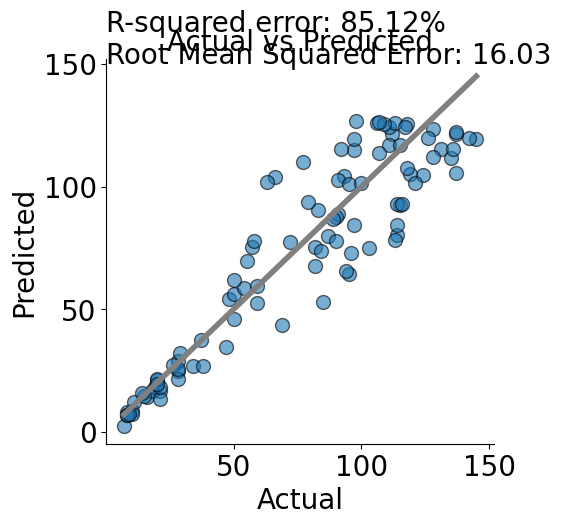

In [ ]:
plt.rcParams['figure.figsize']=5,5

fig,ax = plt.subplots()
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=y_test,
                y=y_predictions_lstm,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(y_test),max(y_test)],
             y=[min(y_test),max(y_test)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(sklearn.metrics.r2_score(y_test, y_predictions_lstm)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(np.sqrt(mean_squared_error(y_test, y_predictions_lstm)))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

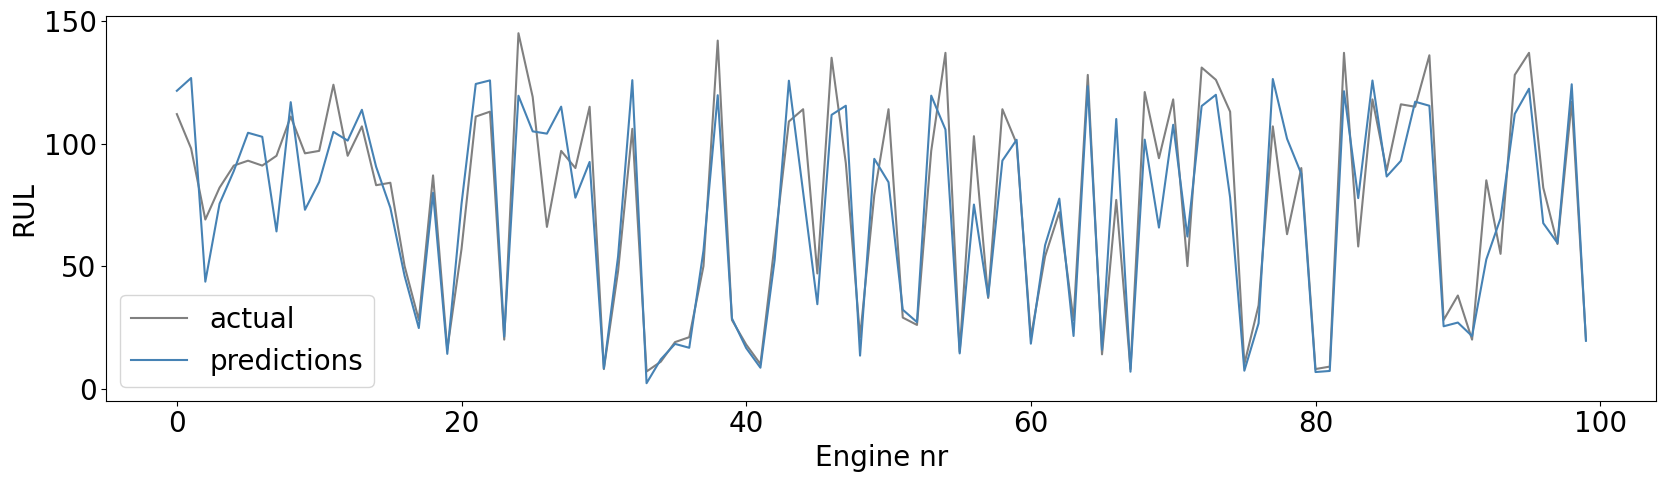

In [ ]:
plt.rcParams['figure.figsize']=20,5

fig,ax = plt.subplots()
plt.ylabel('RUL')
plt.xlabel('Engine nr')

g = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_test,
                color='gray',
                label = 'actual',
                ax=ax)

f = sns.lineplot(x = np.arange(0,len(df_test['engine'].unique())),
                y=y_predictions_lstm,
                color='steelblue',
                label = 'predictions',
                ax=ax)
ax.legend()

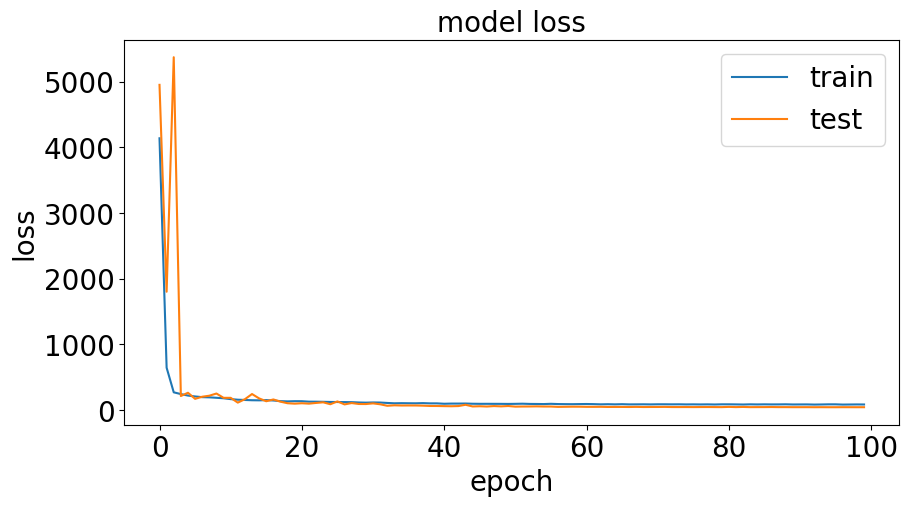

In [ ]:
plt.rcParams['figure.figsize']=5,5
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 8
plt.rcParams['lines.linewidth'] = 1.5
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'])
plt.show()

# Model Selection

In [ ]:
# Display the full model performance table
model_performance

,R2,RMSE,MAE,time to train,time to predict,total time
Linear Regression,0.706210,22.524154,17.774107,0.052202,0.000443,0.052644
Random Forest,0.815900,17.830231,13.311600,50.770037,0.161706,50.931743
XGBoost,0.804862,18.356960,13.983792,1.386948,0.006982,1.393930
LSTM,0.851237,16.027916,12.232685,1774.814551,1.328654,1776.143204


In [ ]:
# Select the best model by lowest RMSE
best_model_name = model_performance['RMSE'].idxmin()
best_score      = model_performance.loc[best_model_name, 'RMSE']

print(f'Best model : {best_model_name}')
print(f'Best RMSE  : {best_score:.4f}')

Best model : LSTM
Best RMSE  : 16.0279


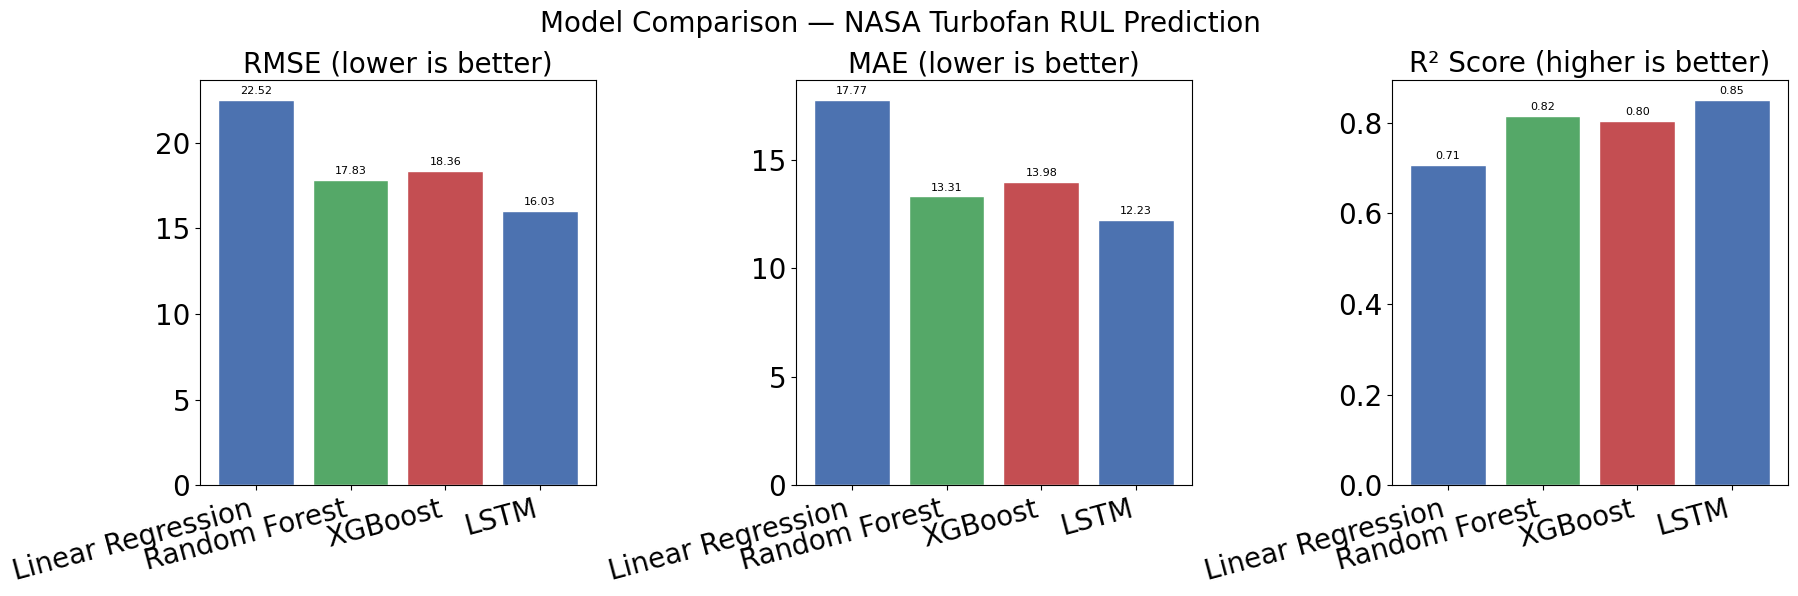

In [ ]:
# Bar chart comparison of all three models
models = model_performance.index.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, title in zip(
    axes,
    ['RMSE', 'MAE', 'R2'],
    ['RMSE (lower is better)', 'MAE (lower is better)', 'R² Score (higher is better)']
):
    vals = model_performance[metric].astype(float)
    bars = ax.bar(models, vals, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            '{:.2f}'.format(val),
            ha='center', va='bottom'
        )

plt.suptitle('Model Comparison — NASA Turbofan RUL Prediction')
plt.tight_layout()
plt.show()

The LSTM achieved the best performance of all four models, with an R² of 85.12 and an RMSE of 16.03 cycles — narrowly edging out Random Forest (R² 81.6, RMSE 17.83). The actual vs. predicted scatter plot shows predictions tracking the diagonal closely, particularly at lower RUL values where accuracy matters most for maintenance decisions. The per-engine line plot confirms the model captures the general degradation pattern well across all 100 test engines, though it struggles with sharp peaks near the RUL cap of 125. The loss curve shows rapid convergence within the first 5 epochs, with train and validation loss staying tightly coupled through all 100 epochs: a good sign of generalization with no meaningful overfitting. The main tradeoff is training time: at ~29 minutes, the LSTM is by far the slowest model, roughly 35× slower than Random Forest, which is worth noting for any production deployment.

# Conclusions

This project focused on NASA’s CMAPSS FD001 dataset to teach four different computer models, Linear Regression, Random Forest, XGBoost, and LSTM, how to guess how much longer a turbofan jet engine would last. The main idea was to see if the information from the engine's sensors, while it was running, could really tell how many more times it could run before something went wrong. This way, maintenance crews could step in and fix things before they got serious.

Out of all the models, the LSTM one performed the best. It got an R² score of 85.12% and its average error, or RMSE, was about 16 cycles. This highlights how useful models that can remember sequences are. The LSTM model could pick up on these gradual changes by looking at data chunks over 30 cycles, something simpler models can't really do. The Random Forest model was a close second, with an R² of 81.6% and an RMSE of 17.83 cycles. This shows that even tree-based models are still very strong contenders, especially since they're much quicker to train. Linear Regression struggled with how complicated engine wear is, so it mostly just gave us a basic benchmark.

The data being prepared utilizing the models made a huge difference in how well they worked. The sensors were removed and weren't changing at all because they didn't really show anything useful. We also used a method called backward stepwise regression to trim down any predictors that didn't seem to have a strong statistical link. And by setting a limit for Remaining Useful Life at 125 cycles, we made sure all the models concentrated on that critical period when an engine is nearing its end. Getting predictions right in that window is when it really matters most for operations. Together, all these steps helped clear out the unnecessary clutter and kept our models focused on the most crucial parts of an engine's lifespan for maintenance.

Having an average error, or RMSE, of around 16 cycles means the predictions are usually within roughly two weeks of when an engine would actually fail. This is a useful time frame, giving maintenance teams enough time to plan for unexpected repairs and prevent an engine from breaking down while it is in service. The LSTM model was very accurate for almost all of the 100 test engines. The only minor obstacle was that its predictions tended to be a bit too smooth when the Remaining Useful Life was still long, around the 125-cycle cap. It was harder for the model to distinguish between engines that still had a lot of life left in that range.

There is always a trade-off. For this project, it was how much computing power and time the models needed. The LSTM took about 29 minutes to learn, which is about 35 times longer than the Random Forest model. This is something important to consider for practical applications, especially if these models need to be constantly updated with new engine information. If one prioritizes how quickly a model can be trained and how easily one can understand why it made a certain prediction, then Random Forest might be the better pick, even if it's slightly less accurate.

Overall, what this project really showed is that machine learning, especially the advanced deep learning methods, can spot signs of an engine wearing out by looking at all sorts of sensor data. It can then give us Remaining Useful Life estimates that are good enough to genuinely help with predictive maintenance. If models like these are used more widely, they could significantly reduce unexpected repairs, bring down operating costs, and most crucially, make flying safer. Engineers would get an early warning when an engine's health is getting risky, long before it becomes a problem.
